In [73]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
import warnings
warnings.filterwarnings('ignore')

# New imports for anomaly detection
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL

# Set up plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_theme(style="whitegrid")

In [74]:
ROOT_PATH='/content/drive/MyDrive/W8/d1/data/artificialWithAnomaly'
FILES=[file for file in os.listdir(ROOT_PATH) if file.endswith('.csv')]
LABEL_PATH='/content/drive/MyDrive/W8/d1/label.json'
print(FILES)

import json
LABELS = None
with open(LABEL_PATH, 'r') as f:
    LABELS = json.load(f)

['art_load_balancer_spikes.csv', 'art_daily_jumpsdown.csv', 'art_daily_nojump.csv', 'art_increase_spike_density.csv', 'art_daily_jumpsup.csv', 'art_daily_flatmiddle.csv']


# Multivariate IF


In [139]:
all_values_list = []

for file in FILES:
    file_path = os.path.join(ROOT_PATH, file)
    temp_df = pd.read_csv(file_path)
    all_values_list.append(temp_df[['value']])

combined_df = pd.concat(all_values_list, axis=0).reset_index(drop=True)

# Re-train with unified feature names
global_window = 288
X_global, _ = create_features_local(combined_df['value'], window=global_window)

global_contamination = 0.05
global_if = IsolationForest(
    n_estimators=200,
    contamination=global_contamination,
    random_state=42
)

global_if.fit(X_global)

with open('global_isolation_forest.pkl', 'wb') as f:
    pickle.dump(global_if, f)

print(f"Đã huấn luyện lại mô hình IF với tên đặc trưng chuẩn hóa.")

Đã huấn luyện lại mô hình IF với tên đặc trưng chuẩn hóa.


In [153]:
from typing import Optional, List
import pickle
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from scipy.stats import skew

def calc_metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

def detect_zscore(series, window=60, threshold=3.0):
    s = pd.Series(series)
    rolling_mean = s.rolling(window=window, min_periods=1).mean()
    rolling_std = s.rolling(window=window, min_periods=1).std()
    rolling_std = rolling_std.replace(0, 1e-10)
    z_scores = (s - rolling_mean) / rolling_std
    return (np.abs(z_scores) > threshold).astype(int)

def detect_ewma(series, alpha=0.3, threshold=3.0):
    s = pd.Series(series)
    ewma = s.ewm(alpha=alpha).mean()
    ewma_std = s.ewm(alpha=alpha).std()
    ewma_std = ewma_std.replace(0, 1e-10)
    deviation = np.abs(s - ewma) / ewma_std
    return (deviation > threshold).astype(int)

def detect_stl(series, period=1440, threshold=3.0):
    stl = STL(series, period=period, robust=True)
    res = stl.fit()
    residual = res.resid
    anomalies = (np.abs(residual - np.mean(residual)) > threshold * np.std(residual)).astype(int)
    return anomalies

def detect_iqr(series, threshold=1.5):
    Q1, Q3 = np.percentile(series, [25, 75])
    IQR = Q3 - Q1
    return ((series < (Q1 - threshold * IQR)) | (series > (Q3 + threshold * IQR))).astype(int)

def create_features_local(series, window=60):
    s = pd.Series(series)
    features = pd.DataFrame({
        'value': s,
        'rolling_mean': s.rolling(window, min_periods=1).mean(),
        'rolling_std': s.rolling(window, min_periods=1).std(),
        'diff': s.diff(),
        'lag_1': s.shift(1),
        'lag_window': s.shift(window)
    })
    valid_idx = features.dropna().index
    return features.dropna(), valid_idx

def make_isolation_forest_local(series, window=60, contamination=0.02):
    X, idx = create_features_local(series, window=window)
    clf = IsolationForest(n_estimators=200, contamination=contamination, random_state=42)
    preds = clf.fit_predict(X)
    full_labels = pd.Series(0, index=series.index)
    full_labels.loc[idx] = np.where(preds == -1, 1, 0)
    return full_labels, clf

def run(file_path: str, data_per_minute: int = 5):
    df = pd.read_csv(file_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    fn = os.path.basename(file_path)

    print(f"--- Statistics for {fn} ---")
    print(df.describe())
    val_skew = skew(df['value'])
    print(f"Skewness of 'value': {val_skew:.4f}")

    plt.figure(figsize=(8, 3))
    sns.histplot(df['value'], kde=True, color='teal')
    plt.title(f"Histogram & Density: {fn}"); plt.show()

    lag_day = (60 * 24) // data_per_minute
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 3))
    plot_acf(df['value'], lags=lag_day, ax=ax1, title=f"ACF Daily: {fn}")
    plot_acf(df['value'], lags=min(lag_day*7, len(df)//2), ax=ax2, title=f"ACF Weekly: {fn}")
    plt.show()

    acf_vals = acf(df['value'], nlags=lag_day)
    period = np.argmax(acf_vals[10:]) + 10
    print(f"Detected Period: {period}")
    return df, int(period)

def run_phase2(df, file_name_short, stl_period, data_per_minute, stat_method, if_contamination_values, global_model=None):
    y_true = pd.Series(0, index=df.index)
    label_key = f'artificialWithAnomaly/{file_name_short}'
    if label_key in LABELS:
        for start_t, end_t in LABELS[label_key]:
            y_true[(df['timestamp'] >= pd.to_datetime(start_t)) & (df['timestamp'] <= pd.to_datetime(end_t))] = 1
    results = []
    if stat_method == 'zscore': df['anomaly_stat'] = detect_zscore(df['value'], window=stl_period)
    elif stat_method == 'ewma': df['anomaly_stat'] = detect_ewma(df['value'])
    elif stat_method == 'stl': df['anomaly_stat'] = detect_stl(df['value'], period=stl_period)
    else: df['anomaly_stat'] = detect_iqr(df['value'])
    p, r, f1 = calc_metrics(y_true, df['anomaly_stat'])
    results.append({'Method': f'Stat ({stat_method})', 'Precision': p, 'Recall': r, 'F1': f1})
    plt.figure(figsize=(15, 2)); plt.plot(df['timestamp'], df['value'], alpha=0.3)
    plt.scatter(df.loc[df['anomaly_stat']==1, 'timestamp'], df.loc[df['anomaly_stat']==1, 'value'], color='red', s=15, label='Stat')
    plt.title(f"Stat Detection: {file_name_short}"); plt.legend(); plt.show()
    if global_model is not None:
        X, idx = create_features_local(df['value'], window=global_window)
        g_preds = global_model.predict(X)
        df['anomaly_global'] = 0
        df.loc[idx, 'anomaly_global'] = np.where(g_preds == -1, 1, 0)
        p, r, f1 = calc_metrics(y_true, df['anomaly_global'])
        results.append({'Method': 'Global IF', 'Precision': p, 'Recall': r, 'F1': f1})
        plt.figure(figsize=(15, 2)); plt.plot(df['timestamp'], df['value'], alpha=0.3)
        plt.scatter(df.loc[df['anomaly_global']==1, 'timestamp'], df.loc[df['anomaly_global']==1, 'value'], color='green', s=15, label='Global IF')
        plt.title(f"Global IF: {file_name_short}"); plt.legend(); plt.show()
    for c in if_contamination_values:
        labels, _ = make_isolation_forest_local(df['value'], window=stl_period, contamination=c)
        p, r, f1 = calc_metrics(y_true, labels)
        results.append({'Method': f'Local IF (c={c})', 'Precision': p, 'Recall': r, 'F1': f1})
        plt.figure(figsize=(15, 2)); plt.plot(df['timestamp'], df['value'], alpha=0.3)
        plt.scatter(df.loc[labels==1, 'timestamp'], df.loc[labels==1, 'value'], color='orange', s=15, label=f'Local IF {c}')
        plt.title(f"Local IF (c={c}): {file_name_short}"); plt.legend(); plt.show()
    display(pd.DataFrame(results).round(4))
    return df

# Metric 1

art_load_balancer_spikes.csv
--- Statistics for art_load_balancer_spikes.csv ---
                 timestamp        value
count                 4032  4032.000000
mean   2014-04-07 23:57:30     0.107572
min    2014-04-01 00:00:00     0.000000
25%    2014-04-04 11:58:45     0.000000
50%    2014-04-07 23:57:30     0.000000
75%    2014-04-11 11:56:15     0.000000
max    2014-04-14 23:55:00     3.224815
std                    NaN     0.442265
Skewness of 'value': 4.8289


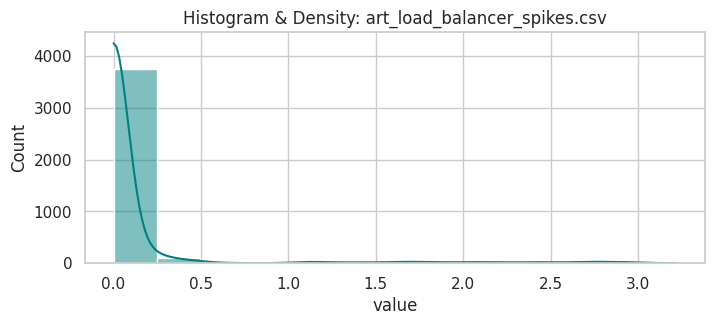

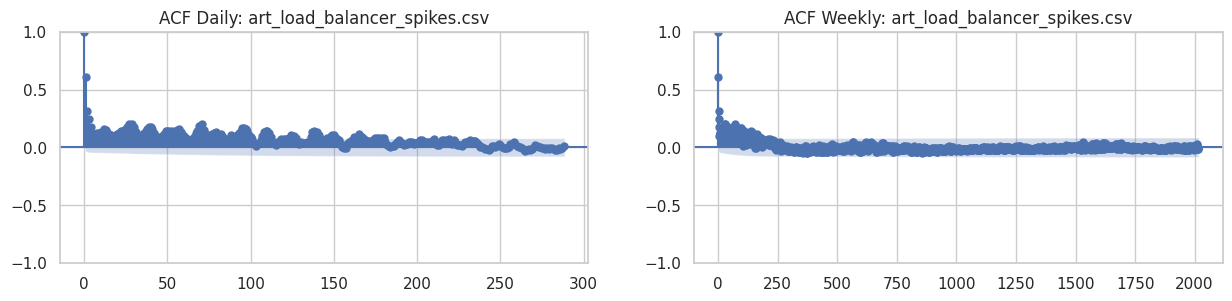

Detected Period: 71


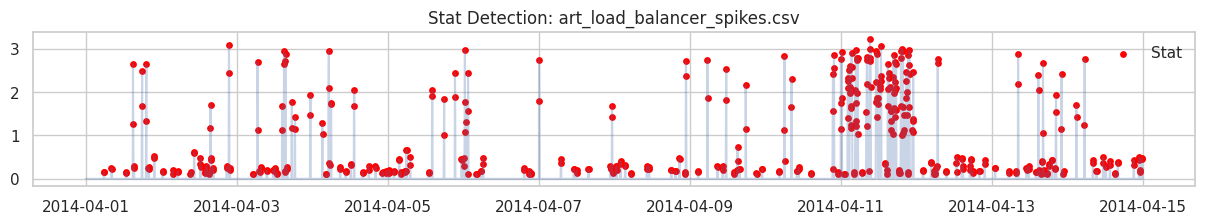

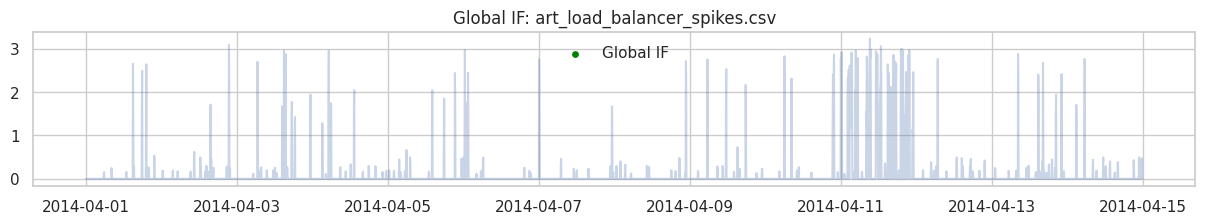

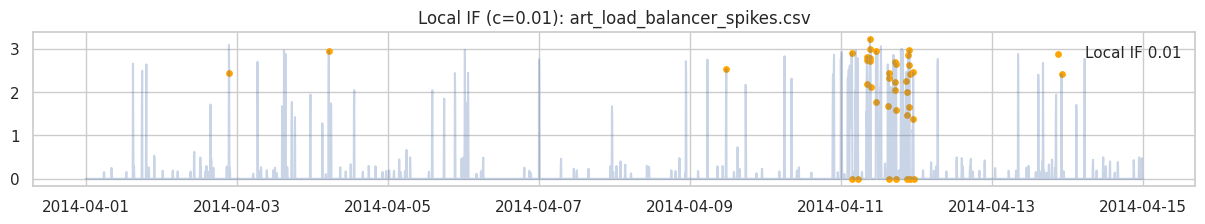

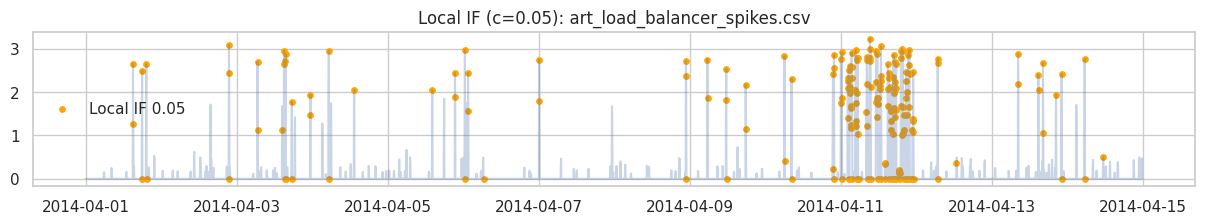

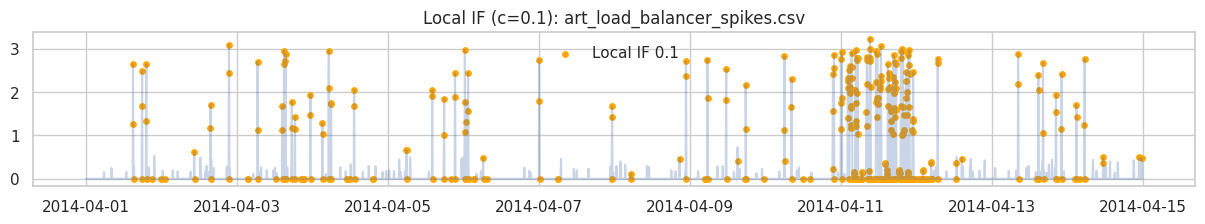

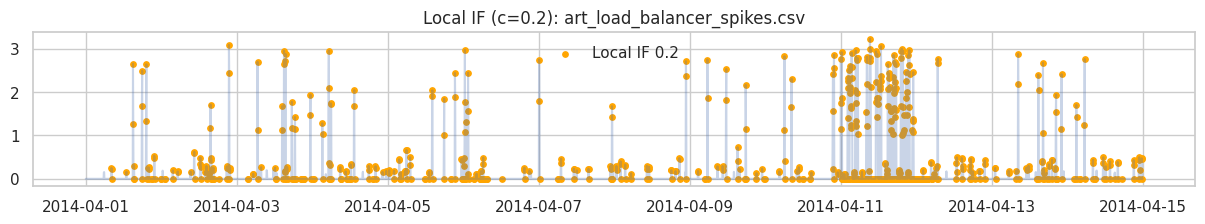

,Method,Precision,Recall,F1
0,Stat (iqr),0.2527,0.2854,0.2681
1,Global IF,0.0000,0.0000,0.0000
2,Local IF (c=0.01),0.6750,0.0670,0.1219
3,Local IF (c=0.05),0.6010,0.2953,0.3960
4,Local IF (c=0.1),0.4520,0.4442,0.4481
5,Local IF (c=0.2),0.3444,0.6700,0.4549


In [154]:
print(FILES[0])
contams = [0.01, 0.05, 0.1, 0.2]
df, period = run(file_path=os.path.join(ROOT_PATH, FILES[0]), data_per_minute=5)
df = run_phase2(df=df, file_name_short=FILES[0], stl_period=period, data_per_minute=5, stat_method='iqr', if_contamination_values=contams, global_model=global_if)

# Metric 2

art_daily_jumpsdown.csv
--- Statistics for art_daily_jumpsdown.csv ---
                 timestamp        value
count                 4032  4032.000000
mean   2014-04-07 23:57:30    41.509772
min    2014-04-01 00:00:00    18.002040
25%    2014-04-04 11:58:45    19.986745
50%    2014-04-07 23:57:30    21.637211
75%    2014-04-11 11:56:15    74.864803
max    2014-04-14 23:55:00    87.998382
std                    NaN    27.512033
Skewness of 'value': 0.6328


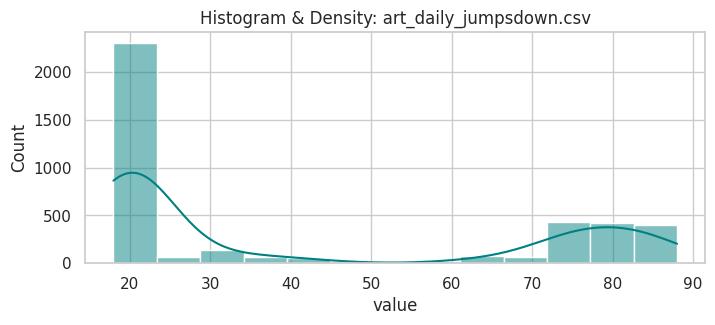

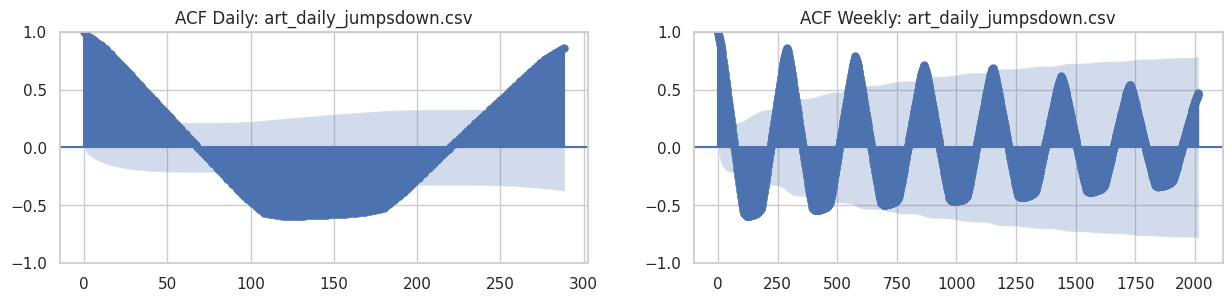

Detected Period: 10


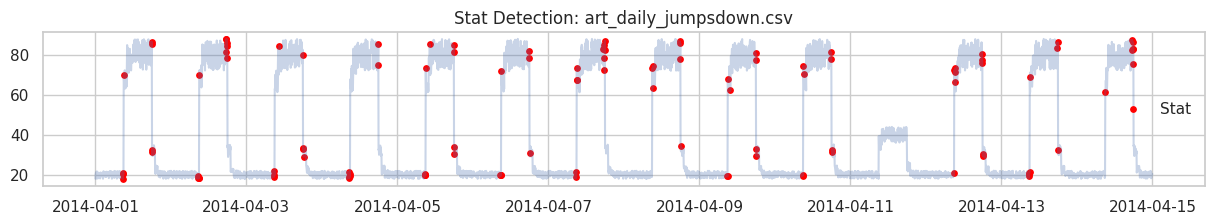

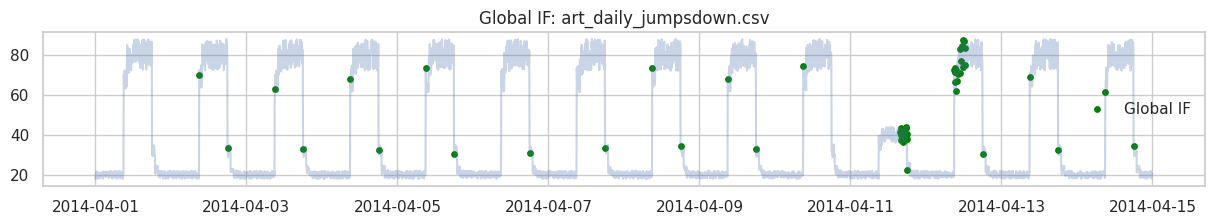

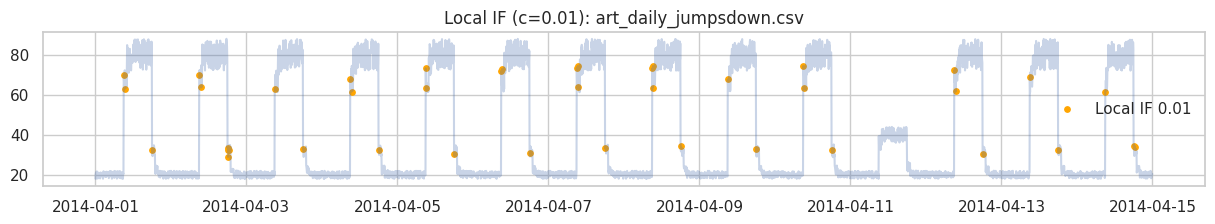

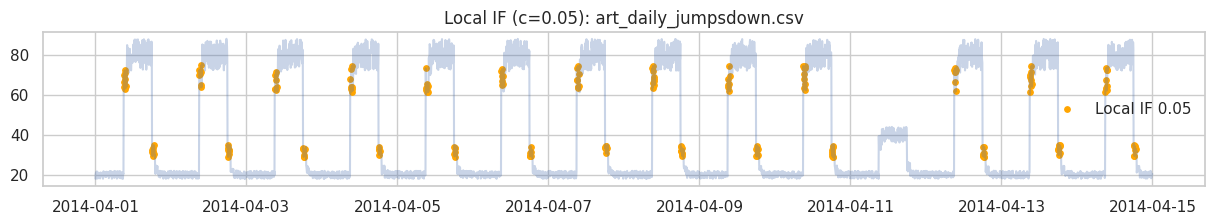

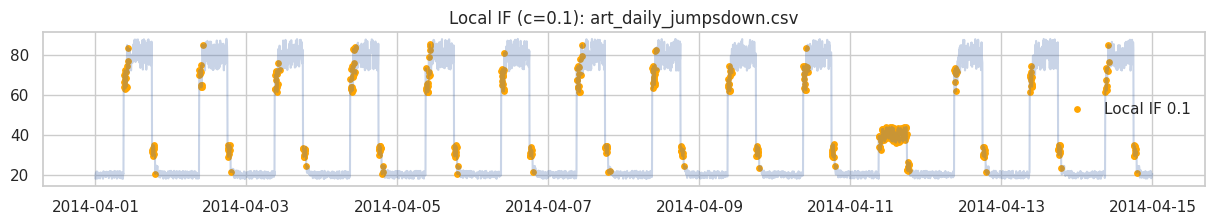

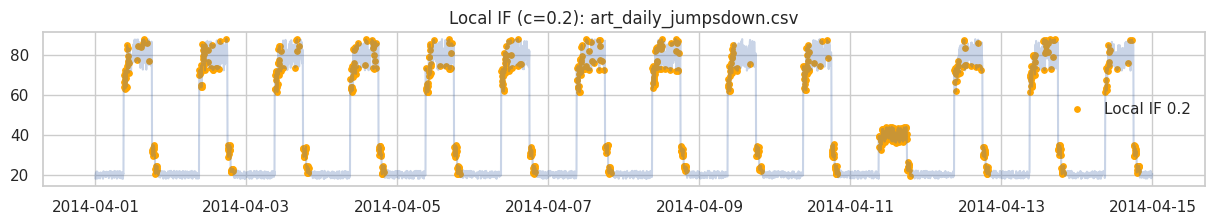

,Method,Precision,Recall,F1
0,Stat (stl),0.0360,0.0099,0.0156
1,Global IF,0.2963,0.0397,0.0700
2,Local IF (c=0.01),0.0244,0.0025,0.0045
3,Local IF (c=0.05),0.0396,0.0199,0.0264
4,Local IF (c=0.1),0.2084,0.2084,0.2084
5,Local IF (c=0.2),0.1776,0.3548,0.2368


In [155]:
print(FILES[1])
contams = [0.01, 0.05, 0.1, 0.2]
df, period = run(file_path=os.path.join(ROOT_PATH, FILES[1]), data_per_minute=5)
df = run_phase2(df=df, file_name_short=FILES[1], stl_period=period, data_per_minute=5, stat_method='stl', if_contamination_values=contams, global_model=global_if)

# Metric 3

art_daily_nojump.csv
--- Statistics for art_daily_nojump.csv ---
                 timestamp        value
count                 4032  4032.000000
mean   2014-04-07 23:57:30    40.818300
min    2014-04-01 00:00:00    18.000501
25%    2014-04-04 11:58:45    19.697373
50%    2014-04-07 23:57:30    21.381511
75%    2014-04-11 11:56:15    74.786987
max    2014-04-14 23:55:00    87.973314
std                    NaN    27.640676
Skewness of 'value': 0.6603


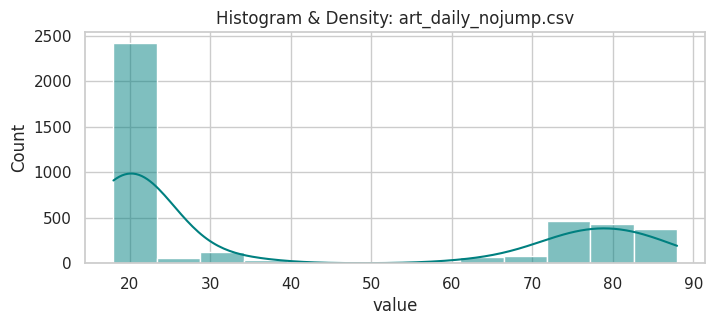

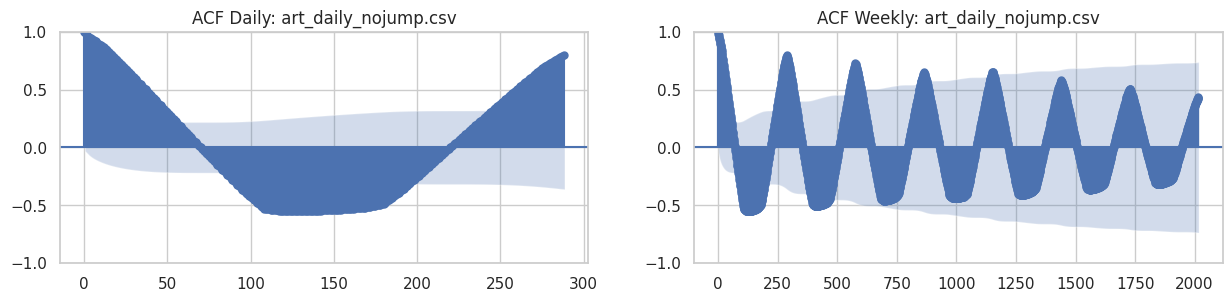

Detected Period: 10


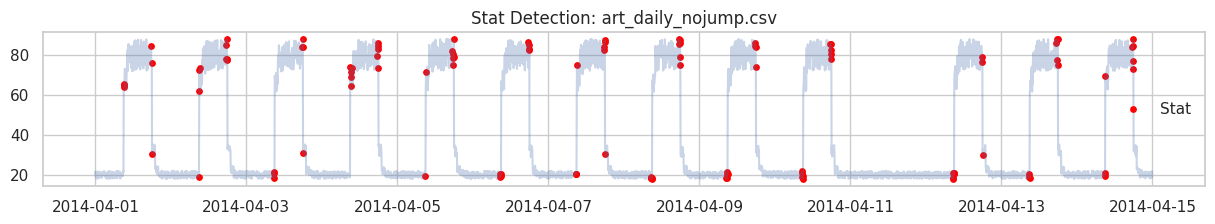

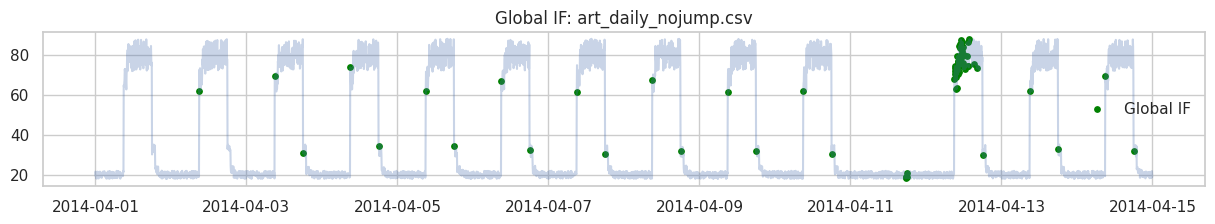

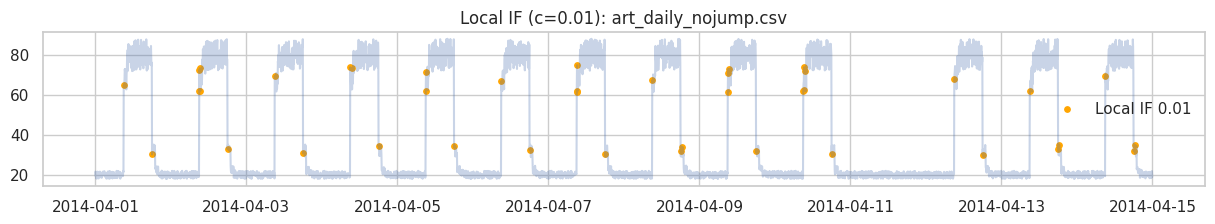

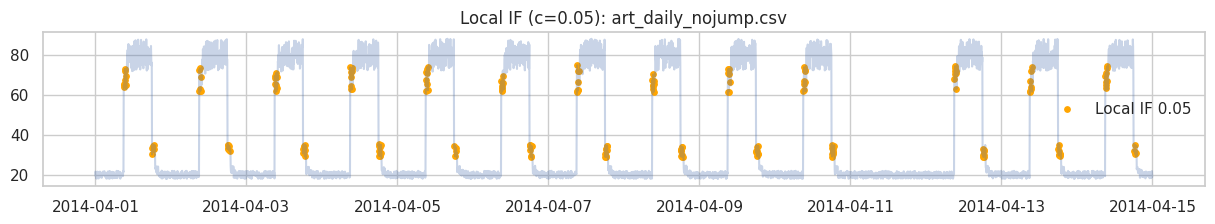

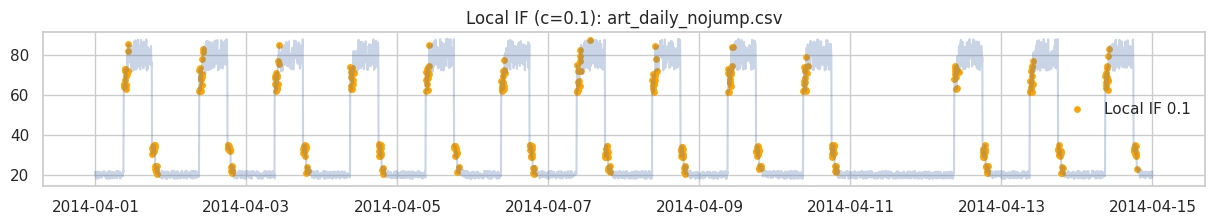

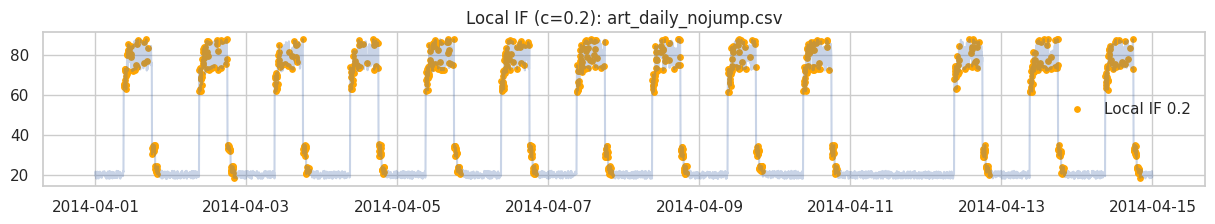

,Method,Precision,Recall,F1
0,Stat (stl),0.0442,0.0124,0.0194
1,Global IF,0.0857,0.0149,0.0254
2,Local IF (c=0.01),0.0244,0.0025,0.0045
3,Local IF (c=0.05),0.0446,0.0223,0.0298
4,Local IF (c=0.1),0.0422,0.0422,0.0422
5,Local IF (c=0.2),0.0311,0.0620,0.0414


In [156]:
print(FILES[2])
contams = [0.01, 0.05, 0.1, 0.2]
df, period = run(file_path=os.path.join(ROOT_PATH, FILES[2]), data_per_minute=5)
df = run_phase2(df=df, file_name_short=FILES[2], stl_period=period, data_per_minute=5, stat_method='stl', if_contamination_values=contams, global_model=global_if)

# Metric 4

art_increase_spike_density.csv
--- Statistics for art_increase_spike_density.csv ---
                 timestamp        value
count                 4032  4032.000000
mean   2014-04-07 23:57:30     0.421627
min    2014-04-01 00:00:00     0.000000
25%    2014-04-04 11:58:45     0.000000
50%    2014-04-07 23:57:30     0.000000
75%    2014-04-11 11:56:15     0.000000
max    2014-04-14 23:55:00    20.000000
std                    NaN     2.873468
Skewness of 'value': 6.6676


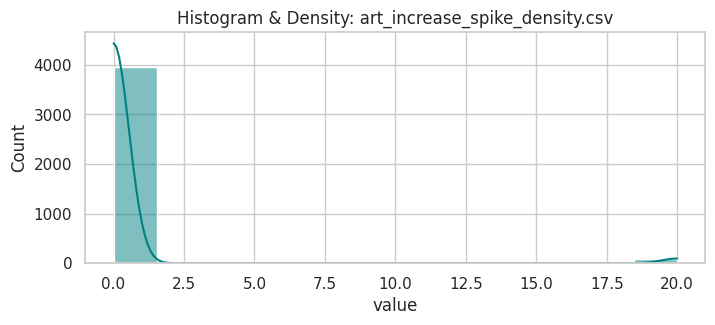

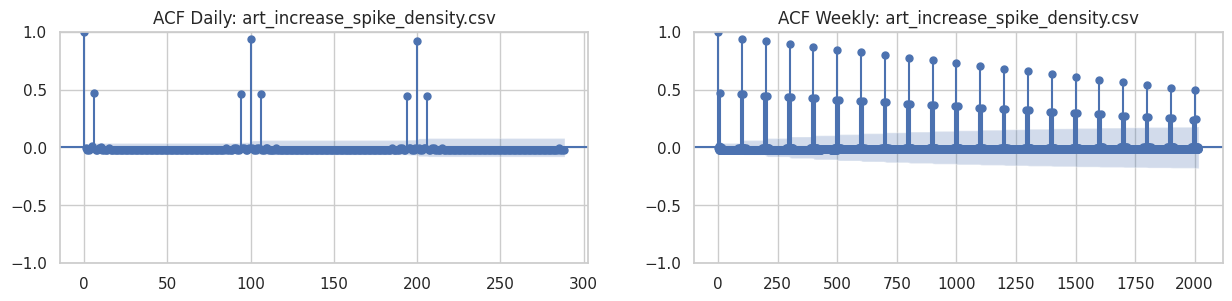

Detected Period: 100


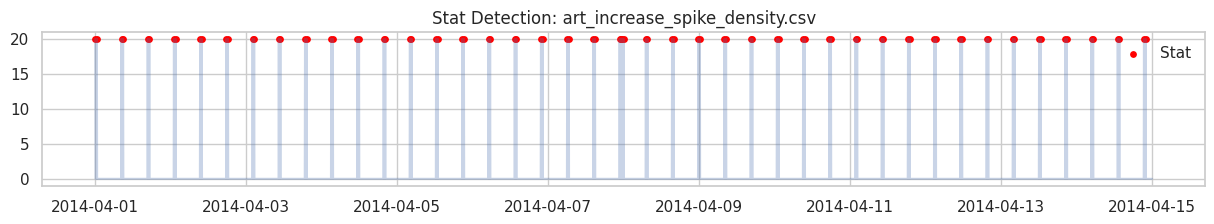

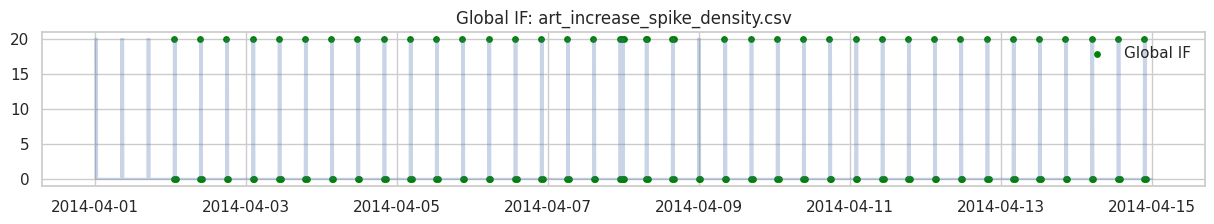

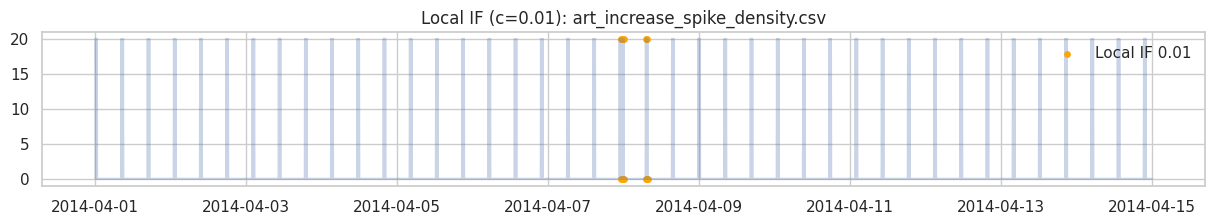

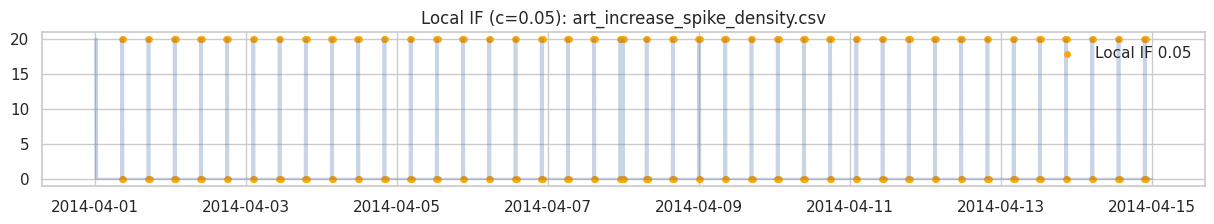

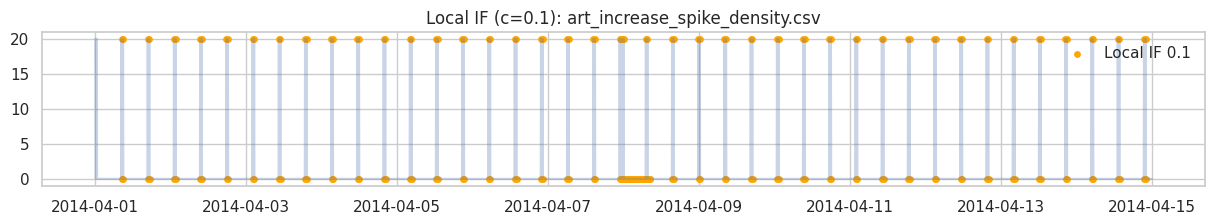

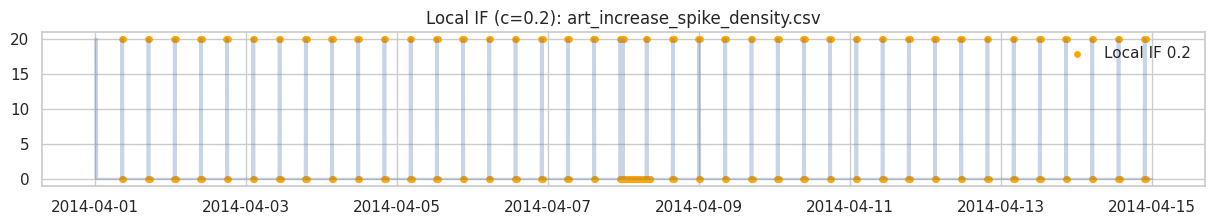

,Method,Precision,Recall,F1
0,Stat (iqr),0.1412,0.0298,0.0492
1,Global IF,0.1597,0.0471,0.0728
2,Local IF (c=0.01),1.0000,0.0273,0.0531
3,Local IF (c=0.05),0.1696,0.0720,0.1010
4,Local IF (c=0.1),0.4642,0.3052,0.3683
5,Local IF (c=0.2),0.4642,0.3052,0.3683


In [157]:
print(FILES[3])
contams = [0.01, 0.05, 0.1, 0.2]
df, period = run(file_path=os.path.join(ROOT_PATH, FILES[3]), data_per_minute=5)
df = run_phase2(df=df, file_name_short=FILES[3], stl_period=period, data_per_minute=5, stat_method='iqr', if_contamination_values=contams, global_model=global_if)

# Metric 5

art_daily_jumpsup.csv
--- Statistics for art_daily_jumpsup.csv ---
                 timestamp        value
count                 4032  4032.000000
mean   2014-04-07 23:57:30    44.494254
min    2014-04-01 00:00:00    18.001010
25%    2014-04-04 11:58:45    19.991382
50%    2014-04-07 23:57:30    21.648503
75%    2014-04-11 11:56:15    76.435943
max    2014-04-14 23:55:00   164.947481
std                    NaN    32.432473
Skewness of 'value': 1.0716


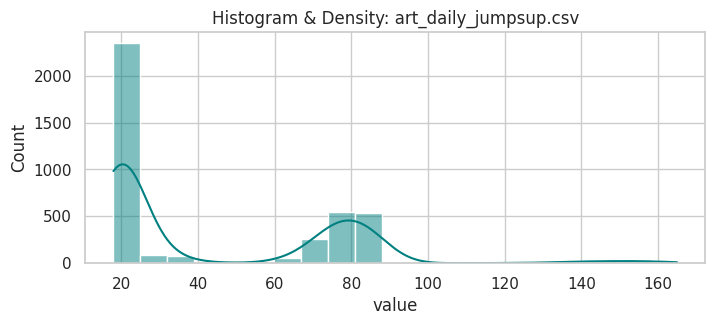

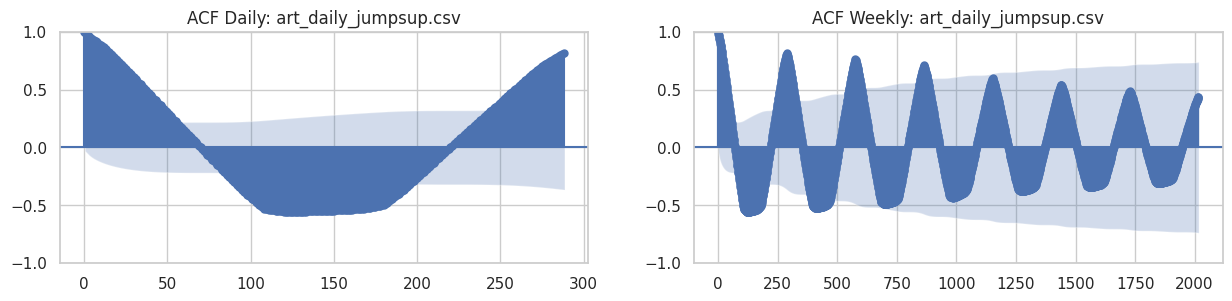

Detected Period: 10


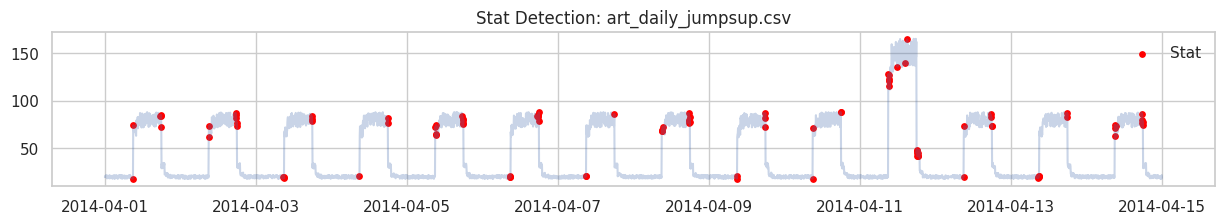

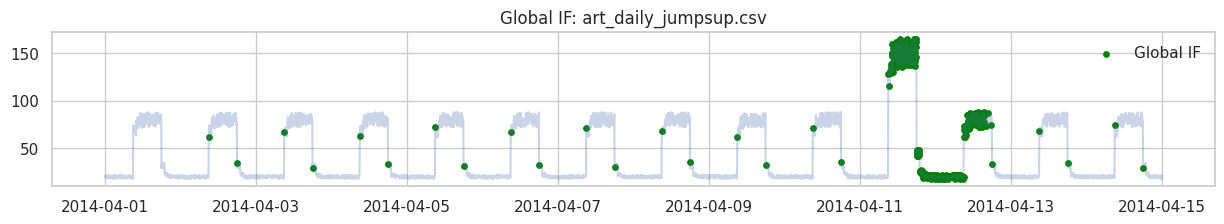

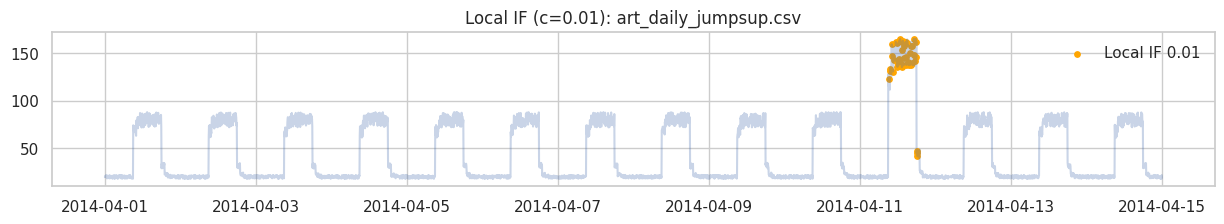

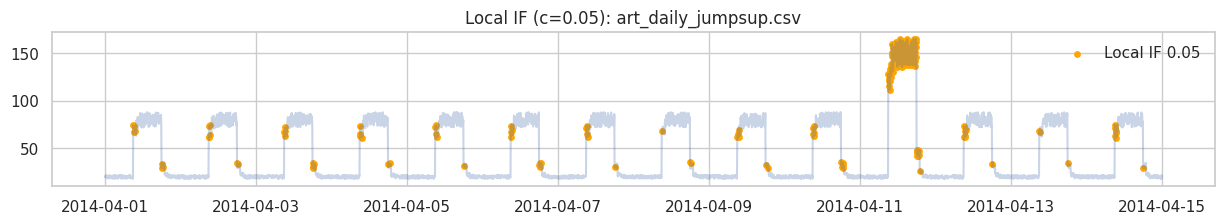

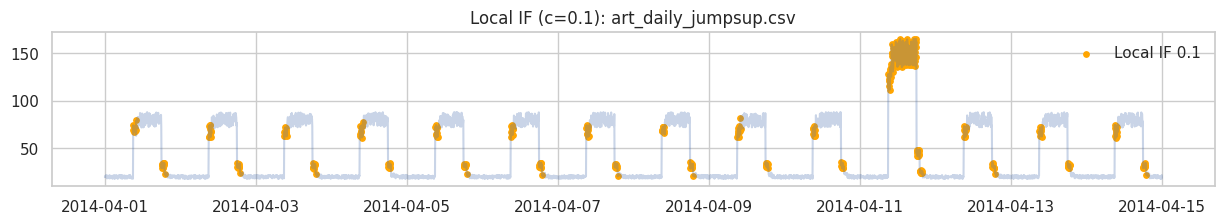

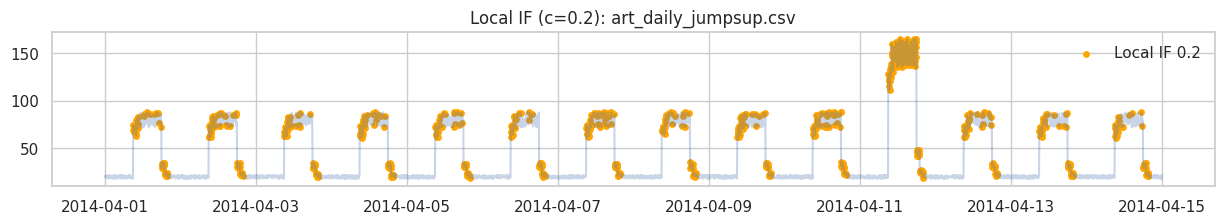

,Method,Precision,Recall,F1
0,Stat (stl),0.1717,0.0422,0.0677
1,Global IF,0.5078,0.4864,0.4968
2,Local IF (c=0.01),1.0000,0.1017,0.1847
3,Local IF (c=0.05),0.6139,0.3077,0.4099
4,Local IF (c=0.1),0.3449,0.3449,0.3449
5,Local IF (c=0.2),0.1950,0.3896,0.2599


In [158]:
print(FILES[4])
contams = [0.01, 0.05, 0.1, 0.2]
df, period = run(file_path=os.path.join(ROOT_PATH, FILES[4]), data_per_minute=5)
df = run_phase2(df=df, file_name_short=FILES[4], stl_period=period, data_per_minute=5, stat_method='stl', if_contamination_values=contams, global_model=global_if)

# Metric 6

art_daily_flatmiddle.csv
--- Statistics for art_daily_flatmiddle.csv ---
                 timestamp        value
count                 4032  4032.000000
mean   2014-04-07 23:57:30    18.981142
min    2014-04-01 00:00:00   -21.998789
25%    2014-04-04 11:58:45   -19.929162
50%    2014-04-07 23:57:30   -17.541296
75%    2014-04-11 11:56:15    74.425223
max    2014-04-14 23:55:00    87.958348
std                    NaN    45.374171
Skewness of 'value': 0.4420


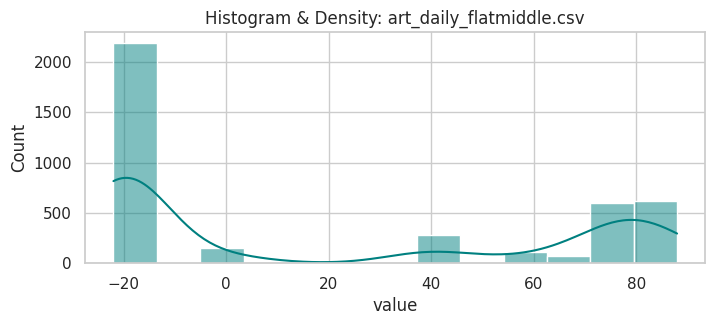

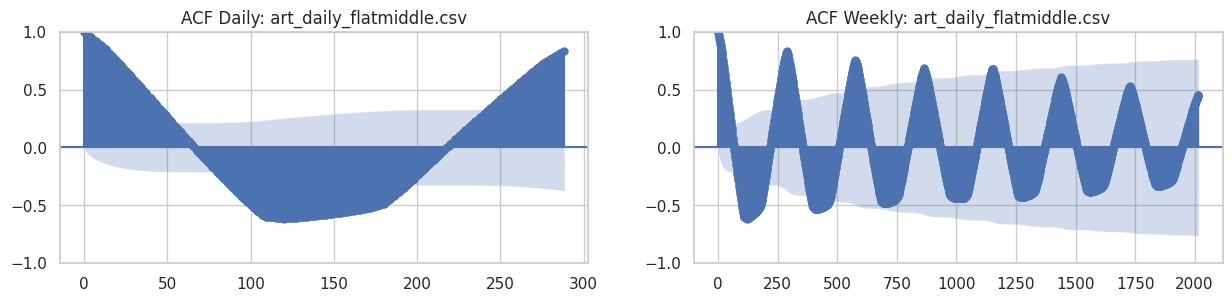

Detected Period: 10


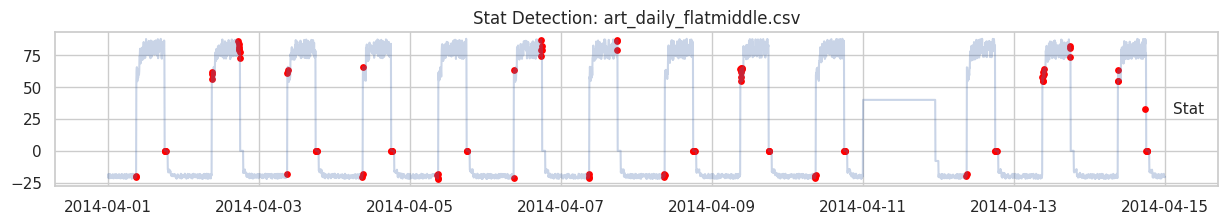

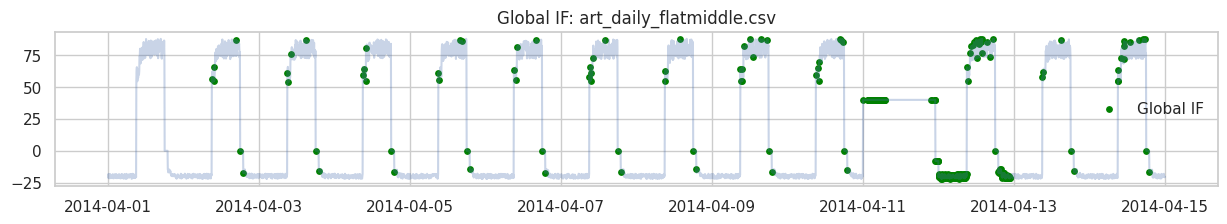

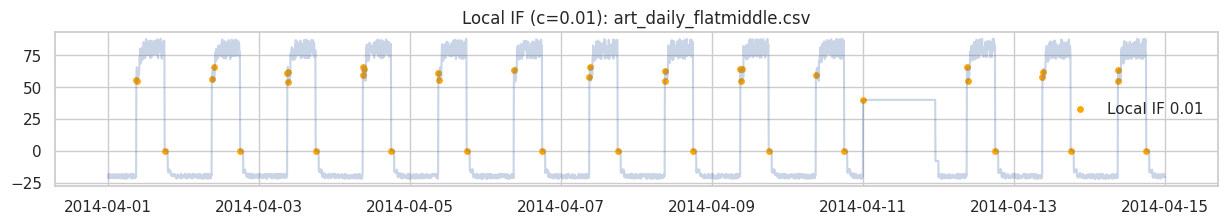

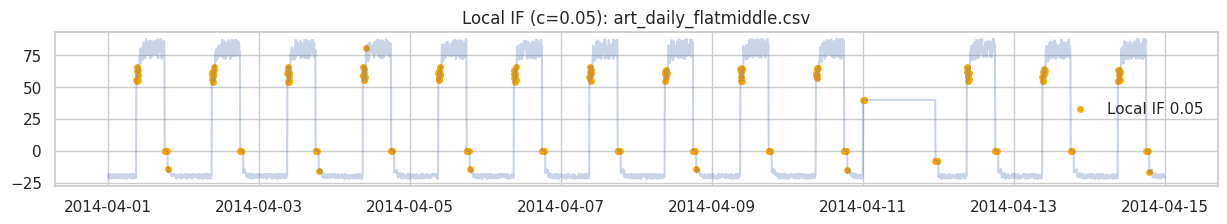

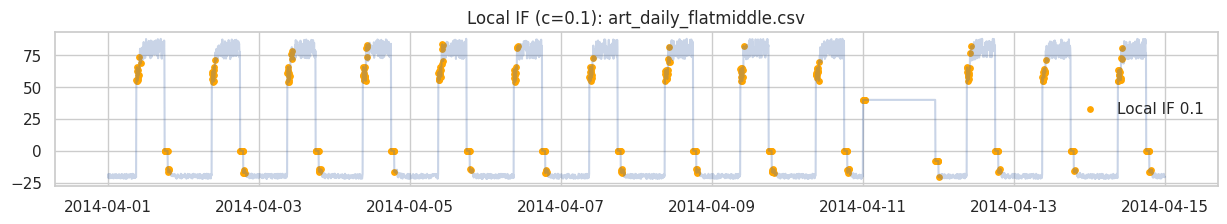

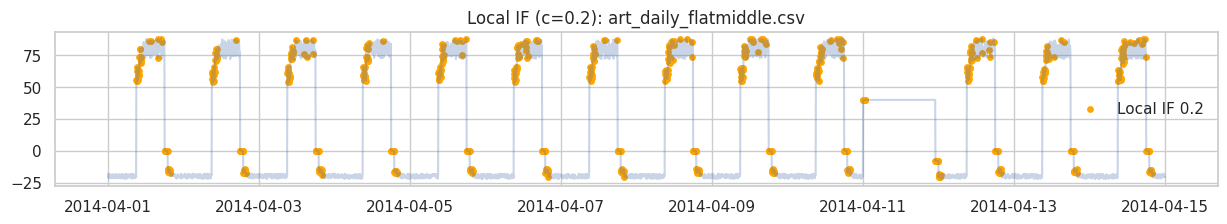

,Method,Precision,Recall,F1
0,Stat (stl),0.0909,0.0248,0.0390
1,Global IF,0.2000,0.1563,0.1755
2,Local IF (c=0.01),0.0732,0.0074,0.0135
3,Local IF (c=0.05),0.0990,0.0496,0.0661
4,Local IF (c=0.1),0.0943,0.0943,0.0943
5,Local IF (c=0.2),0.0938,0.1613,0.1186


In [159]:
print(FILES[5])
contams = [0.01, 0.05, 0.1, 0.2]
df, period = run(file_path=os.path.join(ROOT_PATH, FILES[5]), data_per_minute=5)
df = run_phase2(df=df, file_name_short=FILES[5], stl_period=period, data_per_minute=5, stat_method='stl', if_contamination_values=contams, global_model=global_if)